In [ ]:
%matplotlib widget
from re import I

from dvrptw_bench.dynamic.simulator import DynamicSimulator
from dvrptw_bench.rl.rl4co_policy import RL4COPolicy
from dvrptw_bench.rl.rl_model import build_attention_model
from dvrptw_bench.viz.inspector import inspect_dynamic
from dvrptw_bench.heuristics.ortools_dynamic import ORToolsDVRPTWSolver

from pathlib import Path

from pyarrow import dataset

from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon

dataset_path = Path("../../dataset/solomon_rc100")
instances = [parse_solomon(instance, max_customers=25, distance_scale=100) for instance in find_rc_instances(dataset_path)]
dod = 0.4
cutoff = 0.99
budget_s = 0.1
end_time_closeness = 0.9
soft_time_windows = True
# dynamic_instances = [build_dynamic_scenario(instance, epsilon=dod, seed=42) for instance in instances]

model_weights = [f for f in Path("./model_weights/").glob("*.ckpt")]
print("Model weights found:", model_weights)
sim = DynamicSimulator(instances[0])
am = build_attention_model()
sols = {}
for model_weight in model_weights:
    am.load(model_weight)
    policy = RL4COPolicy(am)
    res = sim.run(lambda instance, time_limit_s, warm_start = None: policy.infer_instance(instance), budget_s=budget_s, epsilon=dod, seed=15, cutoff_ratio=cutoff)
    sols[model_weight.stem] = res[0]
# res = sim.run(lambda instance, time_limit_s, warm_start = None: ORToolsDVRPTWSolver(True).solve(instance, time_limit_s, warm_start), budget_s=budget_s, epsilon=dod, seed=15, cutoff_ratio=cutoff)
# print(res[0].violations)
# inspect_dynamic(instances[0], sim, lambda instance, time_limit_s, warm_start = None: policy.infer_instance(instance), budget_s=budget_s, epsilon=dod, seed=15, cutoff_ratio=cutoff, end_time_closeness=end_time_closeness)



/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of t

Model weights found: [PosixPath('model_weights/attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0005-seed-7960100.ckpt'), PosixPath('model_weights/attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0001-seed-7960100.ckpt'), PosixPath('model_weights/attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0001-seed-6238116.ckpt'), PosixPath('model_weights/attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0005-seed-7454245.ckpt'), PosixPath('model_weights/attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0001-seed-7454245.ckpt'), PosixPath('model_weights/attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0005-seed-6238116.ckpt'), PosixPath('model_weights/attention-model-penalized-RC1-customers-50-penalty-0-lr-0.0001-seed-6238116.ckpt'), PosixPath('model_weights/attention-model-penalized-RC1-customers-50-penalty-0-lr-0.0005-seed-7454245.ckpt'), PosixPath('model_weights/attention-model-penalized-RC1-customers-50-penalty-0-lr-0.0001-seed-7454245.ckpt'

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['baseline.baseline.policy.encoder.init_embedding.init_embed.weight', 'baseline.baseline.policy.encoder.init_embedding.init_embed.bias', 'baseline.baseline.policy.encoder.init_embedding.init_embed_depot.weight', 'baseline.baseline.policy.encoder.init_embedding.init_embed_depot.bias', 'baseline.baseline.policy.encoder.net.layers.0.0.module.Wqkv.weight', 'baseline.baseline.policy.encoder.net.layers.0.0.module.Wqkv.bias', 'baseline.baseline.policy.encoder.net.layers.0.0.module.out_proj.weight', 'baseline.baseline.policy.encoder.net.layers.0.0.module.out_proj.bias', 'baseline.baseline.policy.encoder.net.layers.0.1.normalizer.weight', 'baseline.baseline.policy.encoder.net.layers.0.1.normalizer.bias', 'baseline.baseline.policy.encoder.net.layers.0.1.normalizer.running_mean', 'baseline.baseli

service_start: 26354, c.due_time: 19300.0, completion_time: 27354, lateness: 7054.0
Customer 5 is late.
service_start: 42131, c.due_time: 42000.0, completion_time: 43131, lateness: 131.0
Customer 7 is late.
service_start: 35127, c.due_time: 31500.0, completion_time: 36127, lateness: 3627.0
Customer 11 is late.
service_start: 82682, c.due_time: 77300.0, completion_time: 83682, lateness: 5382.0
Customer 13 is late.
CUstomers length: 25, n_dyn: 10, dynamic_ids: [2, 5, 8, 11, 12, 13, 15, 16, 22, 25]
service_start: 24637, c.due_time: 19300.0, completion_time: 25637, lateness: 5337.0
Customer 5 is late.
service_start: 27471, c.due_time: 27200.0, completion_time: 28471, lateness: 271.0
Customer 2 is late.
service_start: 33303, c.due_time: 32100.0, completion_time: 34303, lateness: 1203.0
Customer 23 is late.
service_start: 34503, c.due_time: 33500.0, completion_time: 35503, lateness: 1003.0
Customer 21 is late.
service_start: 40669, c.due_time: 29400.0, completion_time: 41669, lateness: 11269

In [2]:
# Compare solutions found by the attention model within them
for model_name, sol in sols.items():
    print(f"Model: {model_name}, Violations: {sol.violations}, Total Distance: {sol.total_distance}")


Model: attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0005-seed-7960100, Violations: {'unserved': 0.0, 'late_count': 4.0, 'late_sum': 16194.0, 'capacity': 0.0}, Total Distance: 142076.0
Model: attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0001-seed-7960100, Violations: {'unserved': 0.0, 'late_count': 7.0, 'late_sum': 39683.0, 'capacity': 0.0}, Total Distance: 332342.0
Model: attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0001-seed-6238116, Violations: {'unserved': 0.0, 'late_count': 6.0, 'late_sum': 8280.0, 'capacity': 0.0}, Total Distance: 224134.0
Model: attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0005-seed-7454245, Violations: {'unserved': 0.0, 'late_count': 4.0, 'late_sum': 6473.0, 'capacity': 0.0}, Total Distance: 341071.0
Model: attention-model-penalized-RC1-customers-25-penalty-0-lr-0.0001-seed-7454245, Violations: {'unserved': 0.0, 'late_count': 7.0, 'late_sum': 40557.0, 'capacity': 0.0}, Total Distance: 164056.0
Model: attention-

,model_readable,total_distance,late_count,late_sum,unserved,capacity
0,"c=25, p=0, lr=0.0005, s=7454245",341071.0,4.0,6473.0,0.0,0.0
1,"c=25, p=0, lr=0.0001, s=6238116",224134.0,6.0,8280.0,0.0,0.0
2,"c=50, p=0, lr=0.0001, s=7960100",240397.0,5.0,8574.0,0.0,0.0
3,"c=25, p=0, lr=0.0005, s=7960100",142076.0,4.0,16194.0,0.0,0.0
4,"c=50, p=0, lr=0.0005, s=7960100",236296.0,5.0,16813.0,0.0,0.0
5,"c=50, p=0, lr=0.0001, s=6238116",347723.0,7.0,34088.0,0.0,0.0
6,"c=50, p=0, lr=0.0005, s=6238116",155877.0,10.0,36692.0,0.0,0.0
7,"c=25, p=0, lr=0.0001, s=7960100",332342.0,7.0,39683.0,0.0,0.0
8,"c=25, p=0, lr=0.0001, s=7454245",164056.0,7.0,40557.0,0.0,0.0
9,"c=50, p=0, lr=0.0001, s=7454245",254506.0,7.0,48249.0,0.0,0.0


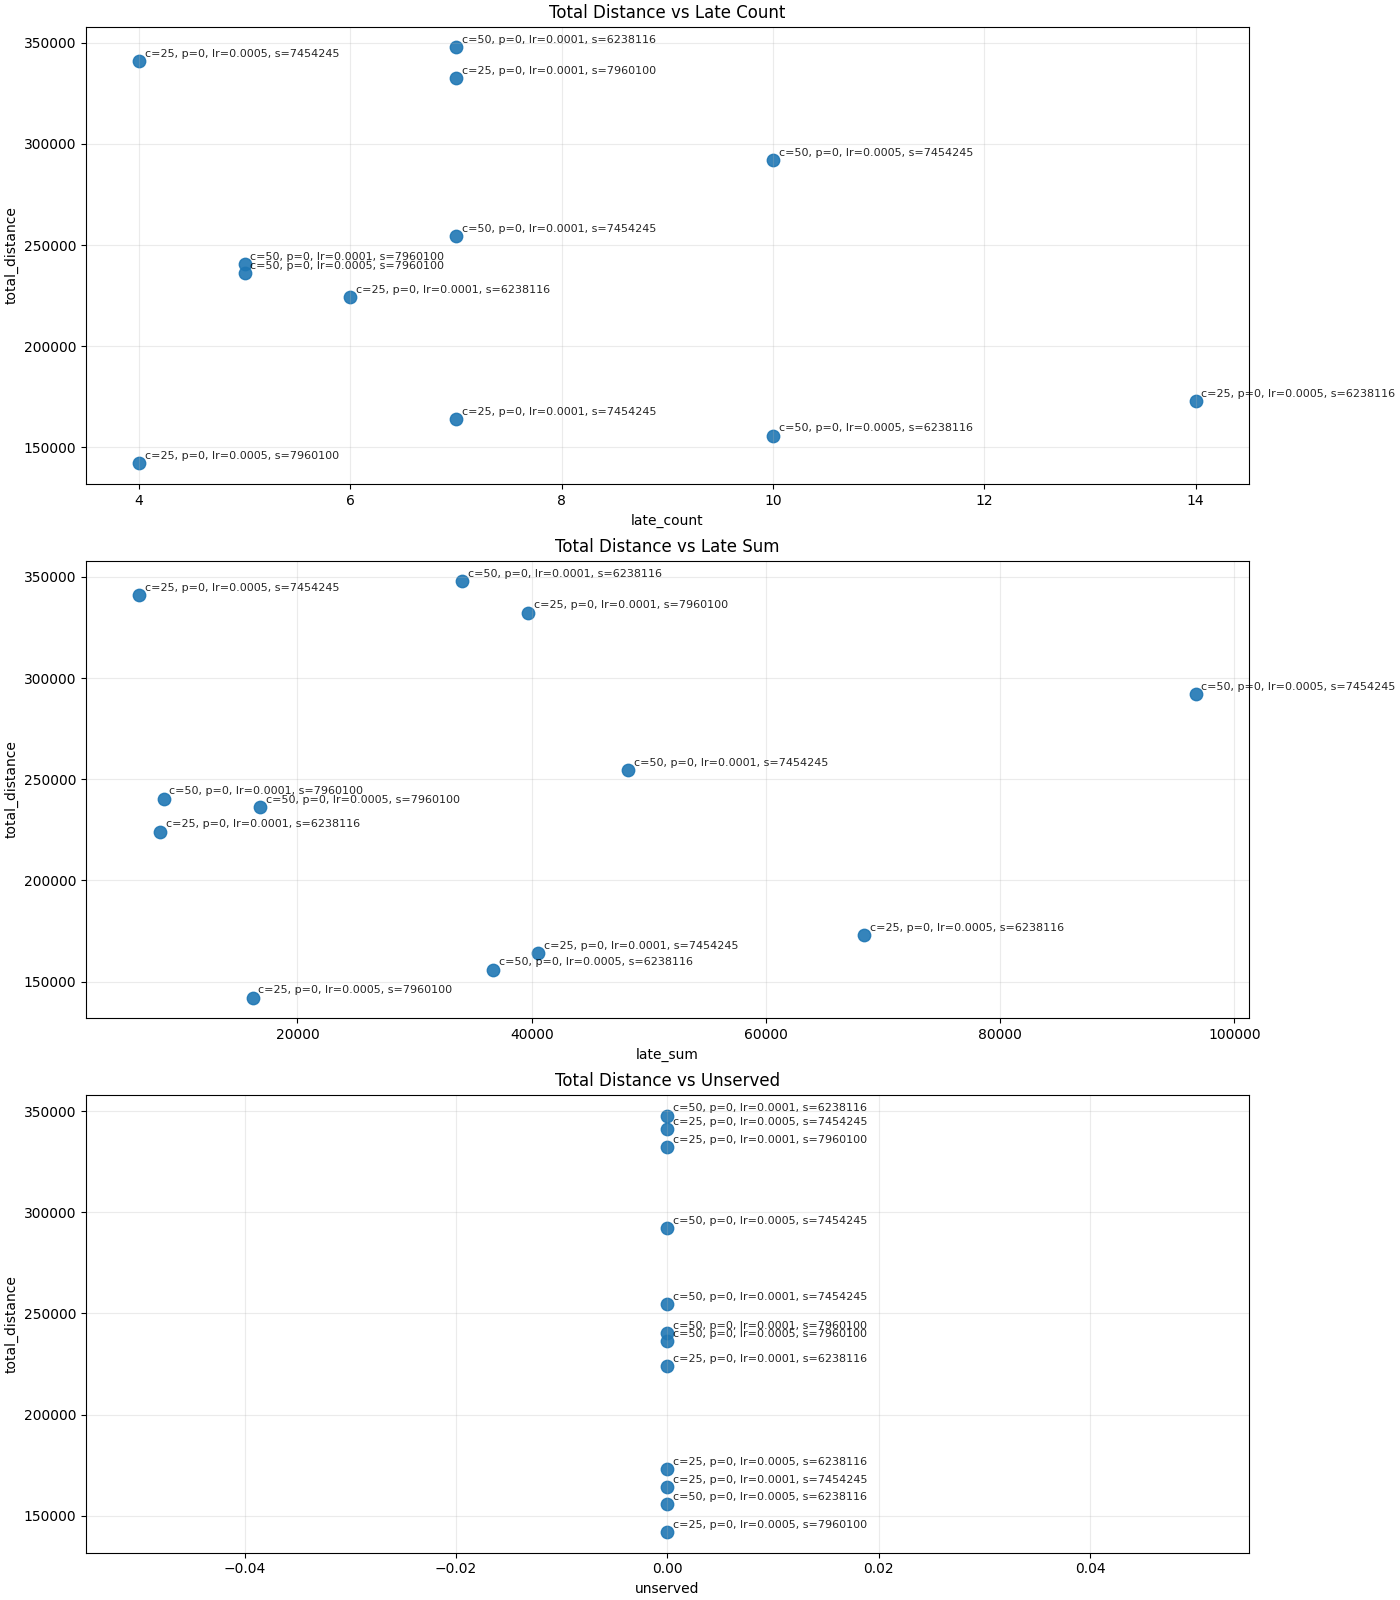

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re


def format_model_name(name: str) -> str:
    match = re.search(r"customers-(\d+)-penalty-(\d+)-lr-(\d*\.?\d+)-seed-(\d+)", name)
    if match:
        customers, penalty, lr, seed = match.groups()
        return f"c={customers}, p={penalty}, lr={lr}, s={seed}"
    return name.replace("attention-model-penalized-", "")


# Build a comparison table from AM solutions
rows = []
for model_name, sol in sols.items():
    violations = sol.violations or {}
    rows.append(
        {
            "model": model_name,
            "model_readable": format_model_name(model_name),
            "total_distance": float(sol.total_distance),
            "unserved": float(violations.get("unserved", 0.0)),
            "late_count": float(violations.get("late_count", 0.0)),
            "late_sum": float(violations.get("late_sum", 0.0)),
            "capacity": float(violations.get("capacity", 0.0)),
        }
    )

df = pd.DataFrame(rows)
df = df.sort_values(["late_sum", "late_count", "total_distance"]).reset_index(drop=True)
display(df[["model_readable", "total_distance", "late_count", "late_sum", "unserved", "capacity"]])

# Plot: each metric on its own row
fig, axes = plt.subplots(3, 1, figsize=(14, 16), constrained_layout=True)

metrics = ["late_count", "late_sum", "unserved"]
titles = ["Total Distance vs Late Count", "Total Distance vs Late Sum", "Total Distance vs Unserved"]

for ax, metric, title in zip(axes, metrics, titles):
    ax.scatter(df[metric], df["total_distance"], s=80, alpha=0.9)
    for _, row in df.iterrows():
        ax.annotate(
            row["model_readable"],
            (row[metric], row["total_distance"]),
            fontsize=8,
            alpha=0.85,
            xytext=(4, 3),
            textcoords="offset points",
        )
    ax.set_xlabel(metric)
    ax.set_ylabel("total_distance")
    ax.set_title(title)
    ax.grid(alpha=0.25)

plt.show()

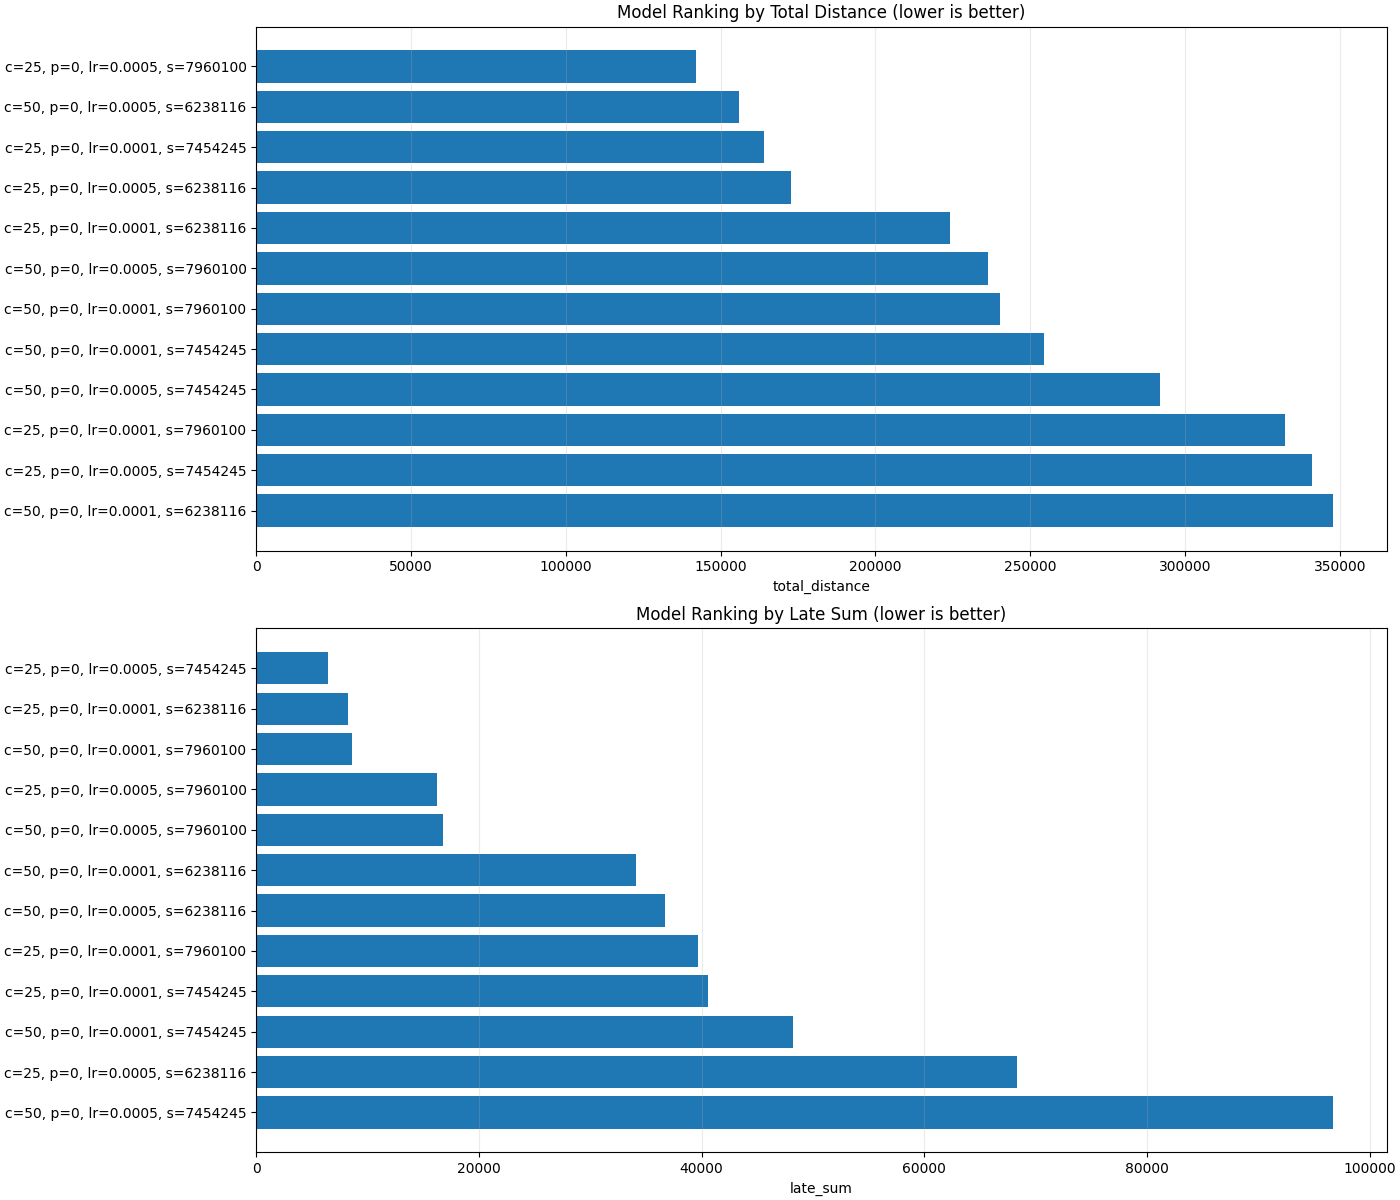

,label,total_distance,late_count,late_sum
3,"c=25, p=0, lr=0.0005, s=7960100",142076.0,4.0,16194.0
6,"c=50, p=0, lr=0.0005, s=6238116",155877.0,10.0,36692.0
8,"c=25, p=0, lr=0.0001, s=7454245",164056.0,7.0,40557.0
10,"c=25, p=0, lr=0.0005, s=6238116",172851.0,14.0,68364.0
1,"c=25, p=0, lr=0.0001, s=6238116",224134.0,6.0,8280.0
4,"c=50, p=0, lr=0.0005, s=7960100",236296.0,5.0,16813.0
2,"c=50, p=0, lr=0.0001, s=7960100",240397.0,5.0,8574.0
9,"c=50, p=0, lr=0.0001, s=7454245",254506.0,7.0,48249.0
11,"c=50, p=0, lr=0.0005, s=7454245",291947.0,10.0,96693.0
7,"c=25, p=0, lr=0.0001, s=7960100",332342.0,7.0,39683.0


In [4]:
# Cleaner comparison: ranked bar charts (one plot per row)
plot_df = df.copy()
plot_df["label"] = plot_df["model"].apply(format_model_name)

by_dist = plot_df.sort_values("total_distance", ascending=True)
by_late = plot_df.sort_values("late_sum", ascending=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 12), constrained_layout=True)

axes[0].barh(by_dist["label"], by_dist["total_distance"])
axes[0].set_title("Model Ranking by Total Distance (lower is better)")
axes[0].set_xlabel("total_distance")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(by_late["label"], by_late["late_sum"])
axes[1].set_title("Model Ranking by Late Sum (lower is better)")
axes[1].set_xlabel("late_sum")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.25)

plt.show()

display(by_dist[["label", "total_distance", "late_count", "late_sum"]])